# Phase 7 — L2 Regularized Logistic Regression

Train a baseline classifier on the fused text+tabular matrix with an L2 weight penalty so the high-dimensional TF-IDF block cannot freely overfit.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

C = 1.0
RANDOM_STATE = 42

## 1. Load fused features and targets

In [2]:
X_train = sparse.load_npz(PROC / "X_train_fused.npz").tocsr()
X_test = sparse.load_npz(PROC / "X_test_fused.npz").tocsr()
y_train = np.load(PROC / "y_train.npy")
y_test = np.load(PROC / "y_test.npy")
feature_names = pd.read_csv(PROC / "fused_feature_names.csv")["feature"].astype(str).to_numpy()

assert X_train.shape[1] == len(feature_names)
print(f"train {X_train.shape} | test {X_test.shape} | success rate train={y_train.mean():.3f}")

train (264728, 2713) | test (66183, 2713) | success rate train=0.404


## 2. Train L2 logistic regression

`C=1.0` is inverse regularization strength (larger C → weaker penalty). We start simple; Phase 8 can sweep strengths.

In [3]:
model = LogisticRegression(
    penalty="l2",
    C=C,
    solver="liblinear",
    max_iter=2000,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

print(f"fitted | n_iter={model.n_iter_} | classes={model.classes_}")

/Users/koriginjasathvik/Desktop/ML_Summer_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


fitted | n_iter=[9] | classes=[0 1]


## 3. Quick holdout scores (full curves in Phase 8)

In [4]:
def eval_split(name, y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "split": name,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "f1": f1_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, proba),
    }


proba_train = model.predict_proba(X_train)[:, 1]
proba_test = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame(
    [
        eval_split("train", y_train, proba_train),
        eval_split("test", y_test, proba_test),
    ]
).round(4)

print(classification_report(y_test, (proba_test >= 0.5).astype(int), digits=4))
metrics

              precision    recall  f1-score   support

           0     0.7110    0.8083    0.7565     39454
           1     0.6454    0.5149    0.5728     26729

    accuracy                         0.6898     66183
   macro avg     0.6782    0.6616    0.6647     66183
weighted avg     0.6845    0.6898    0.6823     66183



,split,accuracy,precision,recall,f1,roc_auc
0,train,0.6957,0.6526,0.5271,0.5832,0.7515
1,test,0.6898,0.6454,0.5149,0.5728,0.7407


### What these scores show

Train vs test gaps tell us whether the L2 model is merely memorizing title tokens. A modest gap with usable test Precision/Recall/F1 is what we want before deeper regularization sweeps.

## 4. Peek at coefficient magnitude by modality

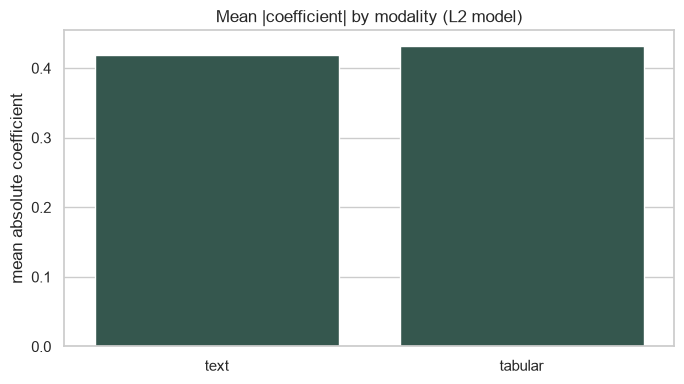

,mean_abs,sum_abs,n_features
modality,,,
tabular,0.4325,92.1209,213
text,0.4187,1046.8254,2500


In [5]:
coefs = model.coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["modality"] = np.where(coef_df["feature"].str.startswith("text__"), "text", "tabular")
coef_df["abs_coef"] = coef_df["coef"].abs()

modality_share = (
    coef_df.groupby("modality")["abs_coef"]
    .agg(mean_abs="mean", sum_abs="sum", n_features="count")
    .round(4)
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=coef_df,
    x="modality",
    y="abs_coef",
    estimator=np.mean,
    errorbar=None,
    color="#2f5d50",
    ax=ax,
)
ax.set_title("Mean |coefficient| by modality (L2 model)")
ax.set_ylabel("mean absolute coefficient")
ax.set_xlabel("")
plt.tight_layout()
fig.savefig(FIG_DIR / "07_mean_abs_coef_by_modality.png", dpi=150)
plt.show()

modality_share

### What this figure shows

Comparing mean absolute coefficients by modality is a quick check that tabular signals still register beside the large text block. Phase 8 plots the actual top positive/negative tokens and tabular weights in detail.

In [6]:
top_pos = coef_df.sort_values("coef", ascending=False).head(10)
top_neg = coef_df.sort_values("coef", ascending=True).head(10)
pd.concat([top_pos.assign(rank_type="top_positive"), top_neg.assign(rank_type="top_negative")])

,feature,coef,modality,abs_coef,rank_type
1825,text__residency,2.425976,text,2.425976,top_positive
1519,text__nudes,2.320901,text,2.320901,top_positive
520,text__cthulhu,2.251761,text,2.251761,top_positive
2249,text__titanium,2.178328,text,2.178328,top_positive
1601,text__pens,2.139228,text,2.139228,top_positive
80,text__arctic,2.099050,text,2.099050,top_positive
2175,text__sxsw,2.062503,text,2.062503,top_positive
573,text__degree,2.059065,text,2.059065,top_positive
2022,text__smartest,2.018751,text,2.018751,top_positive
2229,text__thesis,1.941107,text,1.941107,top_positive


## 5. Save the trained model

In [7]:
joblib.dump(model, PROC / "model_logreg_l2.joblib")
metrics.to_csv(PROC / "model_l2_metrics.csv", index=False)
coef_df.to_csv(PROC / "model_l2_coefficients.csv", index=False)

meta = {
    "model": "LogisticRegression",
    "penalty": "l2",
    "C": C,
    "solver": "liblinear",
    "random_state": RANDOM_STATE,
    "n_features": int(X_train.shape[1]),
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "test_metrics": metrics[metrics["split"] == "test"].iloc[0].drop("split").to_dict(),
}
with open(PROC / "model_l2_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("saved model + metrics to", PROC)
meta

saved model + metrics to /Users/koriginjasathvik/Desktop/ML_Summer_Project/data/processed


{'model': 'LogisticRegression',
 'penalty': 'l2',
 'C': 1.0,
 'solver': 'liblinear',
 'random_state': 42,
 'n_features': 2713,
 'n_train': 264728,
 'n_test': 66183,
 'test_metrics': {'accuracy': 0.6898,
  'precision': 0.6454,
  'recall': 0.5149,
  'f1': 0.5728,
  'roc_auc': 0.7407}}

## Phase 7 takeaways

- Baseline fused model: L2 logistic regression (`C=1.0`, `liblinear`).
- Holdout metrics saved for Phase 8 comparison sweeps.
- Coefficient table ready for top-token / tabular plots.
- Artifacts: `model_logreg_l2.joblib`, `model_l2_metrics.csv`, `model_l2_coefficients.csv`.
- Notes: [`docs/modeling.md`](../docs/modeling.md).